![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [16]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


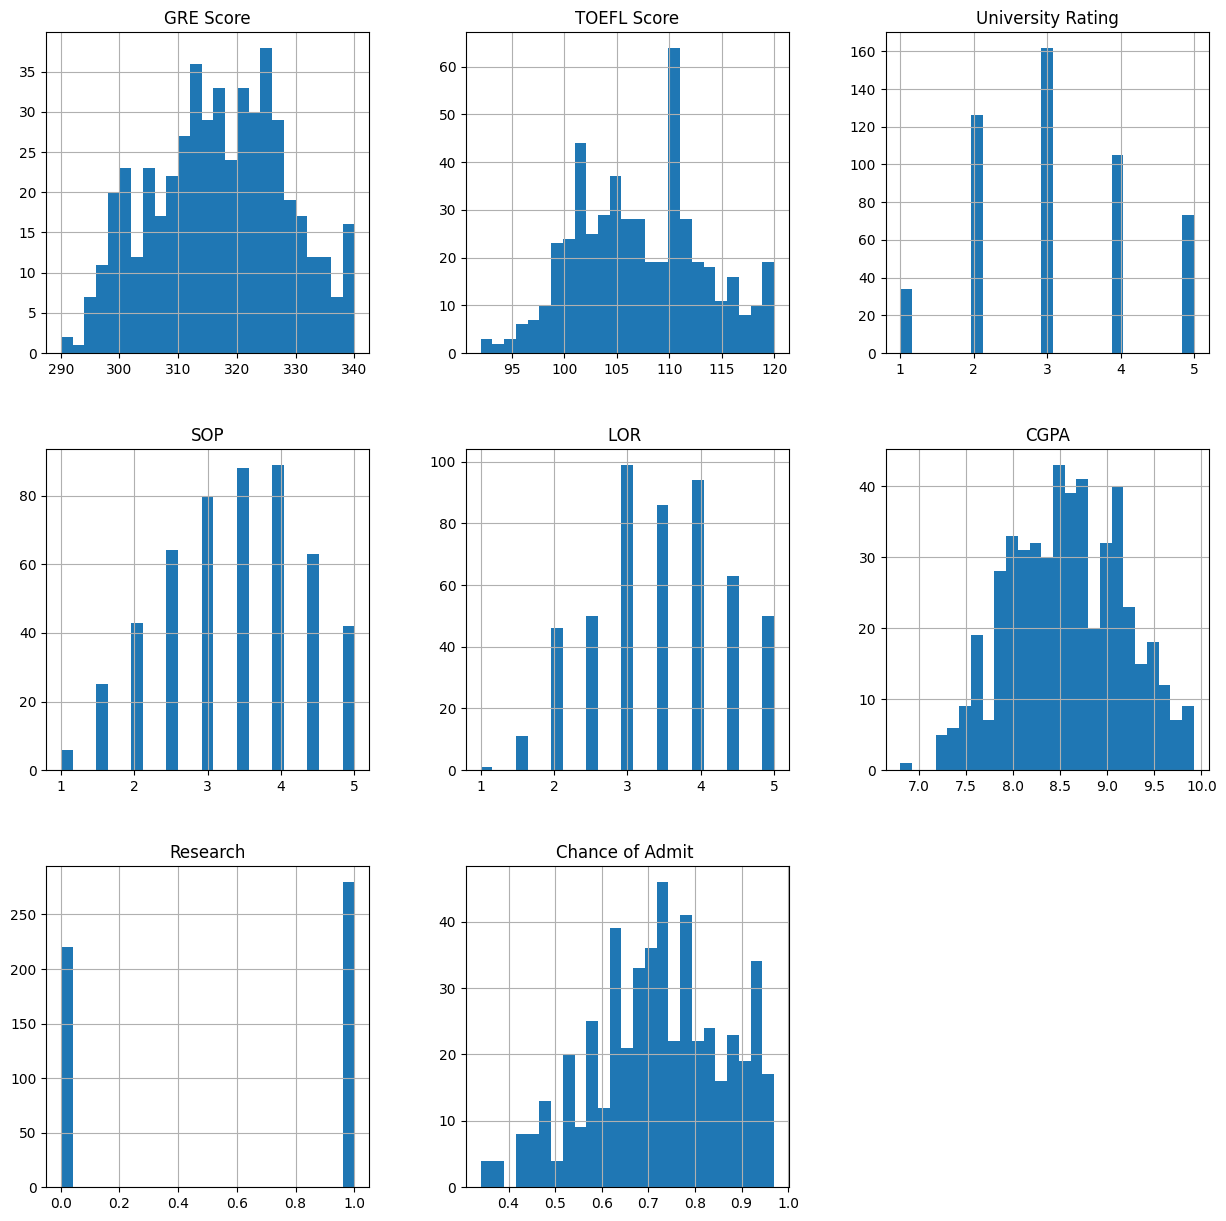

In [17]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [19]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [20]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

In [24]:
# Celda 0 - Escalado de datos (Recomendado para Redes Neuronales)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Ajustamos solo con xTrain para evitar fuga de datos (data leakage)
xTrain_scaled = scaler.fit_transform(xTrain)
xTest_scaled = scaler.transform(xTest)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

Desempeño Modelo 1 (Test) -> MAE: 0.0444 | MSE: 0.0034


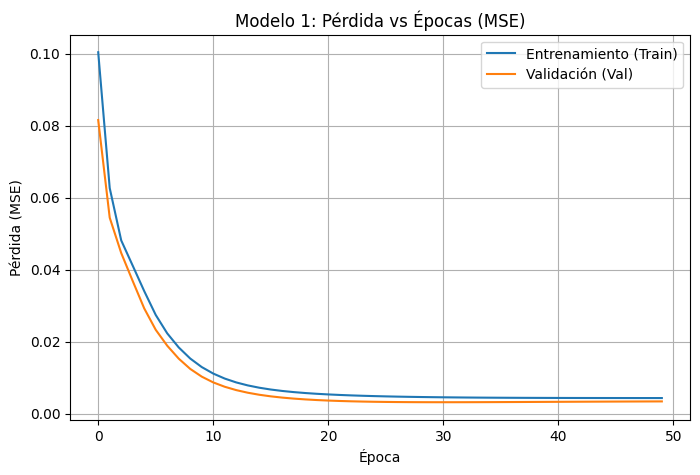

In [26]:
# Celda 1
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# 1. Definición del modelo
modelo_1 = Sequential()
# Una sola capa densa (neurona de salida) para regresión
modelo_1.add(Dense(1, input_dim=xTrain_scaled.shape[1], activation='sigmoid'))

# 2. Compilación
modelo_1.compile(loss='mse', optimizer=optimizers.Adam(learning_rate=0.01), metrics=['mae', 'mse'])

# 3. Entrenamiento del modelo
history_1 = modelo_1.fit(xTrain_scaled, yTrain, epochs=50, validation_split=0.2, verbose=0)

# 4. Evaluación en el set de test
loss_1, mae_1, mse_1 = modelo_1.evaluate(xTest_scaled, yTest, verbose=0)
print(f"Desempeño Modelo 1 (Test) -> MAE: {mae_1:.4f} | MSE: {mse_1:.4f}")

# 5. Gráfica de Pérdida vs Épocas
plt.figure(figsize=(8, 5))
plt.plot(history_1.history['loss'], label='Entrenamiento (Train)')
plt.plot(history_1.history['val_loss'], label='Validación (Val)')
plt.title('Modelo 1: Pérdida vs Épocas (MSE)')
plt.ylabel('Pérdida (MSE)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()

### Justificación Técnica - Modelo 1 (Red de Una Capa)
Para este primer modelo, se define una arquitectura de **una sola capa densa** con una neurona de salida. 

* **Función de Activación:** Se utiliza `sigmoid` debido a que el objetivo es predecir una probabilidad de admisión (valor entre 0 y 1).
* **Función de Pérdida:** Se selecciona el Error Cuadrático Medio (`mse`), ideal para problemas de regresión donde se busca penalizar los errores mayores.
* **Optimizador:** Se emplea **Adam** con una tasa de aprendizaje de `0.01`. Este optimizador es eficiente por su manejo de tasas de aprendizaje adaptativas, permitiendo una convergencia rápida en una estructura lineal simple.
* **Épocas:** Se establecen 50 épocas, suficientes para que un modelo de pocos parámetros estabilice su pérdida sin incurrir en costos computacionales innecesarios.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

Desempeño Modelo 2 (Test) -> MAE: 0.0471 | MSE: 0.0041


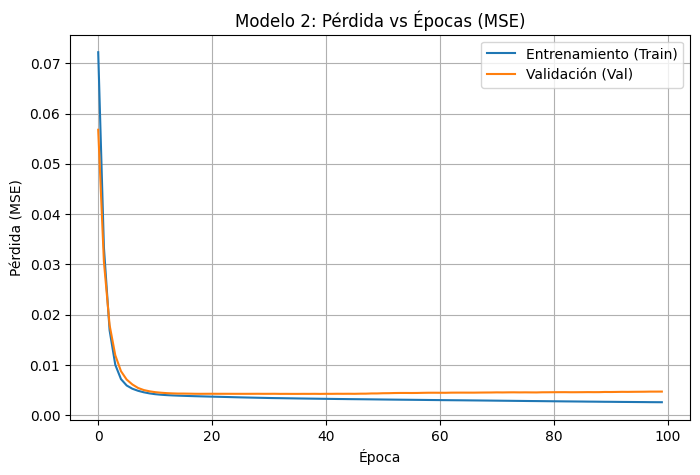

In [28]:
# Celda 2
np.random.seed(42)
tf.random.set_seed(42)

# 1. Definición del modelo
modelo_2 = Sequential()
# Capa oculta
modelo_2.add(Dense(16, input_dim=xTrain_scaled.shape[1], activation='relu'))
# Capa de salida
modelo_2.add(Dense(1, activation='sigmoid'))

# 2. Compilación
modelo_2.compile(loss='mse', optimizer=optimizers.Adam(learning_rate=0.005), metrics=['mae', 'mse'])

# 3. Entrenamiento
history_2 = modelo_2.fit(xTrain_scaled, yTrain, epochs=100, validation_split=0.2, verbose=0)

# 4. Evaluación
loss_2, mae_2, mse_2 = modelo_2.evaluate(xTest_scaled, yTest, verbose=0)
print(f"Desempeño Modelo 2 (Test) -> MAE: {mae_2:.4f} | MSE: {mse_2:.4f}")

# 5. Gráfica de Pérdida vs Épocas
plt.figure(figsize=(8, 5))
plt.plot(history_2.history['loss'], label='Entrenamiento (Train)')
plt.plot(history_2.history['val_loss'], label='Validación (Val)')
plt.title('Modelo 2: Pérdida vs Épocas (MSE)')
plt.ylabel('Pérdida (MSE)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()

### Justificación Técnica - Modelo 2 (Red Multicapa)
En este punto se aumenta la complejidad del modelo para intentar capturar posibles relaciones no lineales en los datos de admisión.

* **Arquitectura:** Se añade una **capa oculta de 16 neuronas** con activación `relu`, la cual ayuda a la red a aprender patrones más complejos que una regresión lineal simple.
* **Optimizador:** Se mantiene **Adam**, pero se reduce la tasa de aprendizaje a `0.005` para permitir que el modelo ajuste sus pesos de forma más fina al tener más parámetros que el Modelo 1.
* **Épocas:** Se incrementa a 100 épocas para dar margen a que la arquitectura multicapa logre la convergencia total, monitoreando la pérdida tanto en el set de entrenamiento como en el de validación.

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

Desempeño Modelo 3 (Test) -> MAE: 0.0447 | MSE: 0.0037
El entrenamiento se detuvo en la época: 171


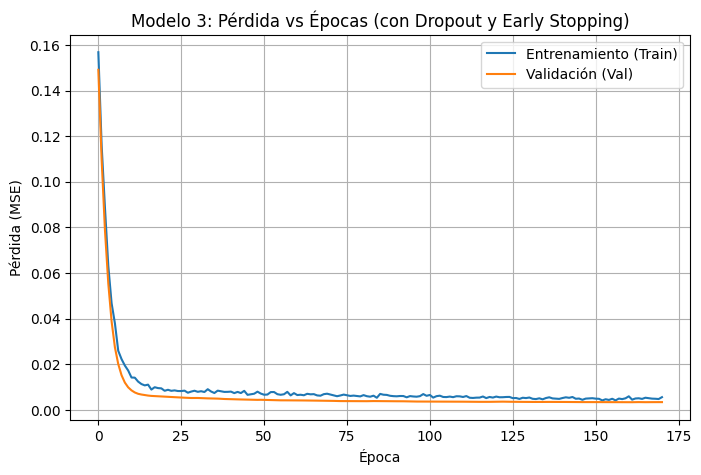

In [29]:
# Celda 3
from keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# 1. Definición del modelo
modelo_3 = Sequential()
modelo_3.add(Dense(32, input_dim=xTrain_scaled.shape[1], activation='relu'))
modelo_3.add(Dropout(0.2)) # Apaga el 20% de las neuronas para evitar sobreajuste
modelo_3.add(Dense(16, activation='relu'))
modelo_3.add(Dropout(0.2))
modelo_3.add(Dense(1, activation='sigmoid'))

# 2. Compilación
modelo_3.compile(loss='mse', optimizer=optimizers.Adam(learning_rate=0.001), metrics=['mae', 'mse'])

# 3. Definición del Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 4. Entrenamiento
history_3 = modelo_3.fit(xTrain_scaled, yTrain, epochs=200, validation_split=0.2, 
                         callbacks=[early_stop], verbose=0)

# 5. Evaluación
loss_3, mae_3, mse_3 = modelo_3.evaluate(xTest_scaled, yTest, verbose=0)
print(f"Desempeño Modelo 3 (Test) -> MAE: {mae_3:.4f} | MSE: {mse_3:.4f}")
print(f"El entrenamiento se detuvo en la época: {len(history_3.history['loss'])}")

# 6. Gráfica de Pérdida vs Épocas
plt.figure(figsize=(8, 5))
plt.plot(history_3.history['loss'], label='Entrenamiento (Train)')
plt.plot(history_3.history['val_loss'], label='Validación (Val)')
plt.title('Modelo 3: Pérdida vs Épocas (con Dropout y Early Stopping)')
plt.ylabel('Pérdida (MSE)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()

### Justificación Técnica - Modelo 3 (Regularización y Early Stopping)
Con el fin de mejorar la capacidad de generalización y combatir el riesgo de sobreajuste observado en modelos más complejos, se aplican técnicas de regularización:

* **Dropout:** Se integra una capa de `Dropout(0.2)` después de cada capa densa. Esto "apaga" aleatoriamente el 20% de las neuronas durante el entrenamiento, obligando a la red a no depender de neuronas específicas y aprender representaciones más robustas.
* **Early Stopping:** Se implementa un callback que monitorea la pérdida de validación (`val_loss`) con una paciencia de 15 épocas. Esto garantiza que el entrenamiento se detenga automáticamente cuando el modelo deje de mejorar, recuperando los mejores pesos encontrados (`restore_best_weights=True`).
* **Configuración:** Se utilizan 32 y 16 neuronas en las capas ocultas para dar capacidad de aprendizaje, compensada por la regularización aplicada.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

# Punto 4 - Comparación y Análisis de Resultados

A continuación, se presenta el resumen de las métricas obtenidas para los tres modelos evaluados en el set de prueba (test):

| Modelo | Descripción | MAE | MSE |
| :--- | :--- | :--- | :--- |
| **Modelo 1** | Red Neuronal de una capa (Lineal) | **0.0444** | **0.0034** |
| **Modelo 2** | Red Neuronal multicapa (16 neuronas) | 0.0471 | 0.0041 |
| **Modelo 3** | Multicapa con Dropout y Early Stopping | 0.0447 | 0.0037 |

---

## 1. Análisis Comparativo

Tras evaluar las tres arquitecturas para predecir la probabilidad de admisión basándose en variables como puntajes **GRE**, **TOEFL** y **CGPA**, se observan los siguientes hallazgos:

* **Predominancia Lineal:** El **Modelo 1** obtuvo el mejor desempeño con el MAE (0.0444) y MSE (0.0034) más bajos. Esto sugiere que la relación entre las variables predictoras y la probabilidad de admisión es mayoritariamente lineal.
* **Impacto de la Regularización:** El **Modelo 3** logró un desempeño superior al Modelo 2 gracias a la implementación de **Dropout** y **Early Stopping**. Las gráficas muestran que el *Dropout* ayudó a la red a generalizar mejor, evitando el sobreajuste.
* **Estabilidad en el Entrenamiento:** El uso de **Early Stopping** permitió detener el entrenamiento cerca de la época 170, garantizando la recuperación de los mejores pesos y evitando el desperdicio de ciclos computacionales.

---

## 2. Ventajas del Mejor Modelo (Modelo 1)

* **Generalización:** Al ser la arquitectura más simple, presenta el menor riesgo de *overfitting*, reflejado en métricas de test más bajas.
* **Eficiencia:** Requiere una fracción del tiempo de entrenamiento y menos recursos de memoria al tener una cantidad mínima de parámetros.
* **Simplicidad:** Facilita la interpretación de cómo las variables (como el promedio académico) impactan directamente la probabilidad final.

---

## 3. Desventajas del Modelo con Menor Desempeño (Modelo 2)

* **Sobreajuste (Overfitting):** Al tener una capa oculta sin mecanismos de regularización, el modelo tendió a memorizar patrones específicos del set de entrenamiento que no se tradujeron al set de test.
* **Complejidad Innecesaria:** Para este volumen de datos y la naturaleza del problema, una arquitectura multicapa estándar introdujo varianza adicional sin aportar precisión real.